# Множества Мандельброта и Джулиа (escape-time)
Используется критерий расхождения $|z|>2$ и максимальное число итераций (по умолчанию 100, при zoom автоматически увеличивается).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

# Для сохранения GIF/MP4 (если доступны библиотеки)
import os
try:
    import imageio.v2 as imageio
except Exception:
    imageio = None

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110


## 1) Математика и алгоритм (escape-time)
Рассматриваем квадратичную итерацию
$$z_{n+1}=z_n^2+c,$$
где $c\in\mathbb{C}$.

**Множество Мандельброта**:
$$\mathcal{M}=\{c:\; z_0=0,\; \{z_n\}\; \text{ограничена}\}.$$
Проверяем «побег» по критерию $|z_n|>2$ (для квадратичного случая это достаточное условие расходимости).

**Множество Джулиа** для фиксированного параметра $c$:
$$K_c = \{z_0:\; \{z_n\}\; \text{ограничена}\},\qquad J_c=\partial K_c.$$

**Раскраска**: число итераций до побега. Для гладких «полос» используем *smooth coloring*:
$$\nu = n + 1 - \log_2(\log|z_n|),$$
где $n$ — номер первой итерации, на которой $|z_n|>2$.

In [2]:
def escape_time_quadratic(C, Z0=None, max_iter=100, escape_radius=2.0, smooth=True):
    """
    Векторизованный escape-time для z_{n+1} = z_n^2 + C.

    Parameters
    ----------
    C : 2D ndarray of complex
        Комплексная сетка параметров (для Мандельброта) или сетка с константой (для Джулиа).
    Z0 : 2D ndarray of complex or None
        Начальные значения z_0. Если None -> z_0=0 (типично для Мандельброта).
    max_iter : int
        Максимальное число итераций.
    escape_radius : float
        Радиус побега (для квадратичного случая достаточно 2).
    smooth : bool
        Если True — возвращает сглаженное число итераций (вещественное).

    Returns
    -------
    nu : 2D ndarray of float
        "Время побега": целое (smooth=False) или сглаженное (smooth=True).
        Точки, не убежавшие за max_iter, имеют значение max_iter.
    """
    if Z0 is None:
        Z = np.zeros_like(C, dtype=np.complex128)
    else:
        Z = Z0.astype(np.complex128, copy=True)

    it = np.full(C.shape, max_iter, dtype=np.int32)
    mask = np.ones(C.shape, dtype=bool)
    R2 = escape_radius * escape_radius

    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        escaped = (Z.real * Z.real + Z.imag * Z.imag) > R2
        newly_escaped = escaped & mask
        it[newly_escaped] = n + 1
        mask &= ~escaped
        if not mask.any():
            break

    if not smooth:
        return it.astype(float)

    nu = it.astype(np.float64)
    esc = it < max_iter
    if np.any(esc):
        Z_esc = Z[esc]
        # nu = n + 1 - log2(log|Z|)
        nu[esc] = it[esc] + 1 - np.log(np.log(np.abs(Z_esc))) / np.log(2.0)
    return nu


def mandelbrot(xmin=-2.0, xmax=1.0, ymin=-1.5, ymax=1.5, nx=900, ny=700, max_iter=100, smooth=True):
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    C = x[None, :] + 1j * y[:, None]
    nu = escape_time_quadratic(C, Z0=None, max_iter=max_iter, smooth=smooth)
    extent = (xmin, xmax, ymin, ymax)
    return nu, extent


def julia(c, xmin=-1.5, xmax=1.5, ymin=-1.5, ymax=1.5, nx=800, ny=800, max_iter=200, smooth=True):
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    Z0 = x[None, :] + 1j * y[:, None]
    C = np.full_like(Z0, c, dtype=np.complex128)
    nu = escape_time_quadratic(C, Z0=Z0, max_iter=max_iter, smooth=smooth)
    extent = (xmin, xmax, ymin, ymax)
    return nu, extent


## 2) Множество Мандельброта на области $c \in [-2,1]\times[-1.5i,1.5i]$
Цвет соответствует числу итераций до побега (сглаженному).

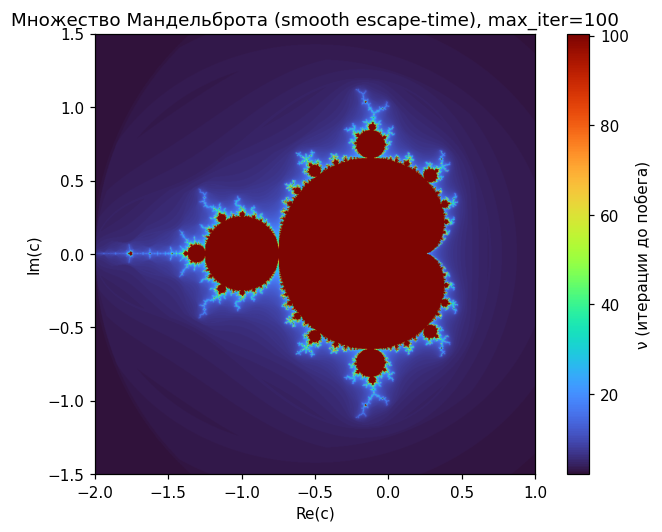

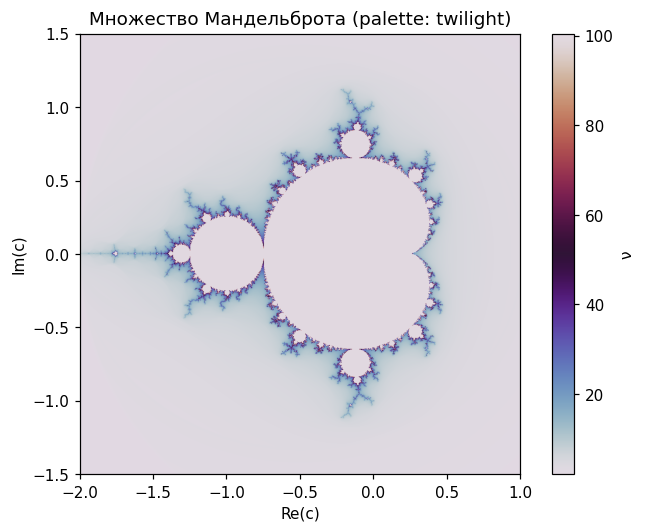

In [3]:
nuM, extM = mandelbrot(nx=1000, ny=800, max_iter=100, smooth=True)

plt.figure(figsize=(7.5, 5.2))
plt.imshow(nuM, extent=extM, origin="lower", cmap="turbo")
plt.title("Множество Мандельброта (smooth escape-time), max_iter=100")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.colorbar(label="ν (итерации до побега)")
plt.show()

plt.figure(figsize=(7.5, 5.2))
plt.imshow(nuM, extent=extM, origin="lower", cmap="twilight")
plt.title("Множество Мандельброта (palette: twilight)")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.colorbar(label="ν")
plt.show()


## 3) Множества Джулиа для нескольких параметров $c$
Ниже — 3–5 параметров из разных областей.

**Критерий связности**: для $f_c(z)=z^2+c$ множество Джулиа $J_c$ **связно тогда и только тогда**, когда $c\in\mathcal{M}$.
Следовательно, **несвязанное $J_c$** получается при $c\notin\mathcal{M}$.

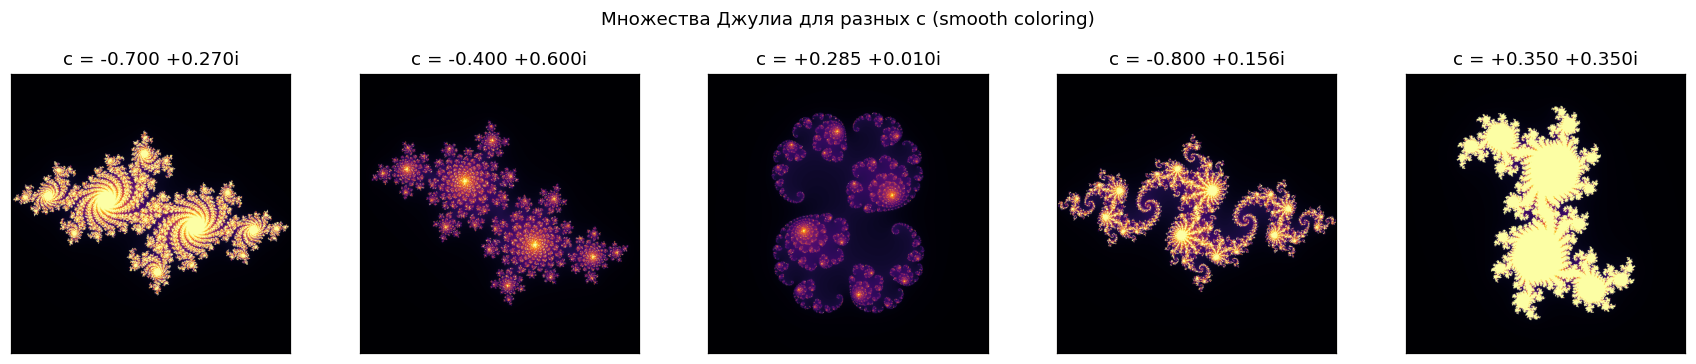

In [4]:
c_list = [
    -0.7 + 0.27j,
    -0.4 + 0.6j,
    0.285 + 0.01j,
    -0.8 + 0.156j,
    0.35 + 0.35j
]

fig, axes = plt.subplots(1, len(c_list), figsize=(3.2*len(c_list), 3.2))
for ax, c in zip(axes, c_list):
    nuJ, extJ = julia(c, nx=520, ny=520, max_iter=220, smooth=True)
    ax.imshow(nuJ, extent=extJ, origin="lower", cmap="inferno")
    ax.set_title(f"c = {c.real:+.3f} {c.imag:+.3f}i")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Множества Джулиа для разных c (smooth coloring)", y=1.02)
plt.tight_layout()
plt.show()


### Быстрая проверка принадлежности $c$ множеству Мандельброта
Запускаем орбиту из $z_0=0$. Если за большое число итераций побега не произошло, точка *вероятно* внутри или на границе $\mathcal{M}$ (пограничные точки требуют больших $N$).

In [5]:
def in_mandelbrot(c, max_iter=4000, escape_radius=2.0):
    z = 0j
    R2 = escape_radius * escape_radius
    for _ in range(max_iter):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) > R2:
            return False
    return True

for c in c_list:
    print(f"c={c: .3f} -> {'внутри/на границе (вероятно)' if in_mandelbrot(c) else 'снаружи (вероятно)'}")


c=-0.700+0.270j -> снаружи (вероятно)
c=-0.400+0.600j -> снаружи (вероятно)
c= 0.285+0.010j -> снаружи (вероятно)
c=-0.800+0.156j -> снаружи (вероятно)
c= 0.350+0.350j -> внутри/на границе (вероятно)


## 4) Zoom в Мандельброт с автоподбором числа итераций
Эвристика:
$$N \approx N_0 + k\log_2(\text{zoom}),\quad \text{zoom}=\frac{\text{base\_width}}{\text{width}}.$$
Здесь `width` — текущая ширина окна по Re.

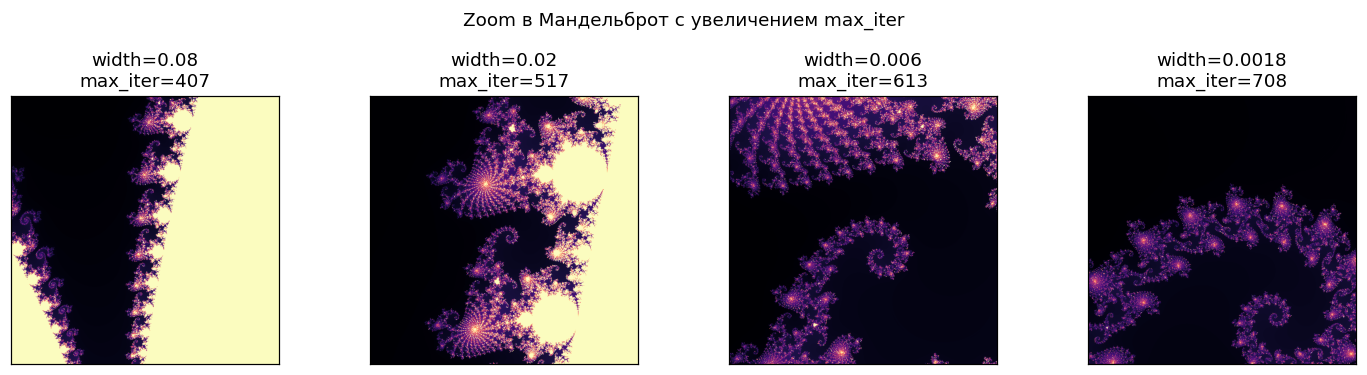

In [6]:
def auto_max_iter(width, base_width=3.0, base_iter=120, k=55, cap=2500):
    zoom = base_width / width
    it = int(base_iter + k * max(0.0, np.log2(zoom)))
    return min(it, cap)

def mandelbrot_zoom(center=(-0.743643887037151, 0.13182590420533), width=0.02, aspect=1.0, nx=900):
    x0, y0 = center
    height = width * aspect
    xmin, xmax = x0 - width/2, x0 + width/2
    ymin, ymax = y0 - height/2, y0 + height/2
    ny = int(nx * aspect)
    mi = auto_max_iter(width)
    nu, ext = mandelbrot(xmin, xmax, ymin, ymax, nx=nx, ny=ny, max_iter=mi, smooth=True)
    return nu, ext, mi

center = (-0.743643887037151, 0.13182590420533)  # "seahorse valley"
widths = [0.08, 0.02, 0.006, 0.0018]

fig, axes = plt.subplots(1, len(widths), figsize=(3.3*len(widths), 3.3))
for ax, w in zip(axes, widths):
    nuZ, extZ, mi = mandelbrot_zoom(center=center, width=w, aspect=1.0, nx=520)
    ax.imshow(nuZ, extent=extZ, origin="lower", cmap="magma")
    ax.set_title(f"width={w:g}\nmax_iter={mi}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Zoom в Мандельброт с увеличением max_iter", y=1.02)
plt.tight_layout()
plt.show()


## 5) Анимация: эволюция $J_c$ при движении $c$ по границе главной кардиоиды
Параметризация границы главной кардиоиды:
$$c(t)=\frac12 e^{it}-\frac14 e^{2it},\ t\in[0,2\pi].$$

AttributeError: 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

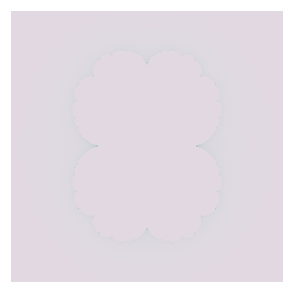

In [7]:
def cardioid_boundary(t):
    return 0.5*np.exp(1j*t) - 0.25*np.exp(2j*t)

n_frames = 60
ts = np.linspace(0, 2*np.pi, n_frames, endpoint=False)
cs = cardioid_boundary(ts)

# Предрасчёт кадров (умеренное разрешение для скорости)
frames = []
for c in cs:
    nu, _ = julia(c, nx=360, ny=360, max_iter=240, smooth=True)
    frames.append(nu)

# Сохраняем GIF в файл (если imageio доступен)
gif_path = "/mnt/data/julia_on_cardioid.gif"
if imageio is not None:
    ims = []
    for nu in frames:
        fig = plt.figure(figsize=(3.2, 3.2))
        plt.axis("off")
        plt.imshow(nu, origin="lower", cmap="twilight")
        fig.canvas.draw()
        w, h = fig.canvas.get_width_height()
        img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)
        plt.close(fig)
        ims.append(img)
    imageio.mimsave(gif_path, ims, duration=0.07)
    print("GIF saved:", gif_path)

# Встроенное HTML-превью (без сохранения во внешний файл)
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(frames[0], origin="lower", cmap="twilight")
ax.set_xticks([]); ax.set_yticks([])
title = ax.set_title("")

def update(k):
    im.set_data(frames[k])
    c = cs[k]
    title.set_text(f"Julia set, c = {c.real:+.3f} {c.imag:+.3f}i")
    return im, title

ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=80, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())


## 6) Соответствие: точки $c$ в Мандельброте и структура $J_c$
Слева — Мандельброт с отмеченными точками параметра $c$.
Справа — соответствующие множества Джулиа $J_c$.

In [ ]:
selected_cs = [
    0.0 + 0.0j,         # внутри
    -0.12 + 0.74j,      # около "кролика"
    -0.75 + 0.1j,       # внутри
    0.35 + 0.35j,       # снаружи -> несвязное
]

nuM2, extM2 = mandelbrot(nx=900, ny=700, max_iter=180, smooth=True)
fig = plt.figure(figsize=(10.8, 6.2))
gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1])

axM = fig.add_subplot(gs[:, 0])
axM.imshow(nuM2, extent=extM2, origin="lower", cmap="turbo")
axM.set_title("Мандельброт + выбранные c")
axM.set_xlabel("Re(c)"); axM.set_ylabel("Im(c)")

for c in selected_cs:
    axM.plot([c.real], [c.imag], marker="o", markersize=6, markeredgecolor="white")

for idx, c in enumerate(selected_cs):
    ax = fig.add_subplot(gs[idx//2, 1 + idx%2])
    nuJ, extJ = julia(c, nx=420, ny=420, max_iter=260, smooth=True)
    ax.imshow(nuJ, extent=extJ, origin="lower", cmap="inferno")
    ax.set_title(f"J_c, c={c.real:+.2f}{c.imag:+.2f}i")
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


## 7) Разные цветовые схемы на одном zoom-кадре
Циклические палитры подчёркивают полосы равного «времени побега»,
а перцептуально-равномерные — геометрию границы.

In [ ]:
nuZ, extZ, mi = mandelbrot_zoom(center=(-0.743643887037151, 0.13182590420533), width=0.006, aspect=1.0, nx=640)

cmaps = ["magma", "inferno", "twilight", "turbo"]
fig, axes = plt.subplots(1, len(cmaps), figsize=(3.2*len(cmaps), 3.2))
for ax, cmap in zip(axes, cmaps):
    ax.imshow(nuZ, extent=extZ, origin="lower", cmap=cmap)
    ax.set_title(cmap)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"Один zoom, разные палитры (max_iter={mi})", y=1.03)
plt.tight_layout()
plt.show()
